# IBM Data Analyst Capstone Project  
## Global Developer Survey – Skill & Salary Analysis

This project was completed as part of the IBM Data Analyst Professional Certificate.  

The objective of this analysis is to explore global developer survey data to identify:

- Skill trends
- Salary distribution patterns
- Technology preferences
- Developer role distribution
- Relationships between age, compensation, and experience

The project covers:
- Data Cleaning & Wrangling
- Exploratory Data Analysis (EDA)
- SQL-based analysis
- Data Visualization


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv"

df = pd.read_csv(dataset_url)

df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


## 1. Data Loading & Initial Exploration

The dataset used in this project is based on a global developer survey.

Initial exploration is performed to:
- Understand dataset structure
- Inspect data types
- Identify missing values
- Determine dataset size

In [10]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11552 entries, 0 to 11551
Data columns (total 85 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Respondent              11552 non-null  int64  
 1   MainBranch              11552 non-null  object 
 2   Hobbyist                11552 non-null  object 
 3   OpenSourcer             11552 non-null  object 
 4   OpenSource              11471 non-null  object 
 5   Employment              11552 non-null  object 
 6   Country                 11552 non-null  object 
 7   Student                 11499 non-null  object 
 8   EdLevel                 11436 non-null  object 
 9   UndergradMajor          10812 non-null  object 
 10  EduOther                11388 non-null  object 
 11  OrgSize                 11454 non-null  object 
 12  DevType                 11485 non-null  object 
 13  YearsCode               11543 non-null  object 
 14  Age1stCode              11539 non-null

,Respondent,CompTotal,ConvertedComp,WorkWeekHrs,CodeRevHrs,Age
count,11552.000000,1.073700e+04,1.073000e+04,11427.000000,9083.000000,11255.000000
mean,12362.212517,7.499932e+05,1.313340e+05,42.051851,4.762829,30.772394
std,7271.939210,9.639522e+06,2.943245e+05,24.528561,4.548401,7.392780
min,4.000000,0.000000e+00,0.000000e+00,3.000000,0.000000,16.000000
25%,6011.500000,2.500000e+04,2.672700e+04,40.000000,2.000000,25.000000
50%,12323.500000,6.500000e+04,5.774400e+04,40.000000,4.000000,29.000000
75%,18686.500000,1.200000e+05,1.000000e+05,43.000000,5.000000,35.000000
max,25142.000000,7.000000e+08,2.000000e+06,1012.000000,99.000000,99.000000


In [11]:
df['Age'].mean()
df['Country'].nunique()

135

### Observations

- The dataset contains thousands of developer responses across multiple countries.
- Most variables are categorical (object type).
- The survey captures demographic, technical, and compensation-related information.

## 2. Data Cleaning & Wrangling

Before performing analysis, the dataset required cleaning to ensure reliability and consistency.

The following steps were performed:

- Removed duplicate responses
- Identified and handled missing values
- Imputed missing Work Location values
- Normalized compensation data to annual compensation

In [12]:
df.drop_duplicates(inplace=True)

### Duplicate Handling

Duplicate responses were removed to ensure that each respondent is counted only once.  
This prevents skewed statistical analysis.

In [13]:
df.isnull().sum()

Respondent        0
MainBranch        0
Hobbyist          0
OpenSourcer       0
OpenSource       81
               ... 
Sexuality       542
Ethnicity       675
Dependents      140
SurveyLength     19
SurveyEase       14
Length: 85, dtype: int64

### Missing Value Treatment

Columns with missing values were analyzed carefully.  
The 'WorkLoc' column was imputed using the most frequent value (mode) to maintain consistency.

In [17]:
df['WorkLoc'].fillna(df['WorkLoc'].mode()[0], inplace=True)

In [18]:
df['NormalizedAnnualCompensation'] = np.where(
    df['CompFreq'] == 'Yearly', df['CompTotal'],
    np.where(df['CompFreq'] == 'Monthly', df['CompTotal'] * 12,
             np.where(df['CompFreq'] == 'Weekly', df['CompTotal'] * 52, np.nan))
)

### Salary Normalization

Since compensation was reported on different frequencies (Yearly, Monthly, Weekly),  
a new column called `NormalizedAnnualCompensation` was created to standardize all salaries into annual values.

This allows accurate salary comparison across respondents.

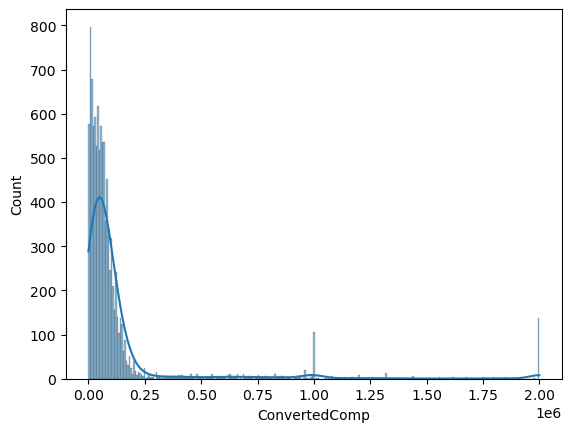

In [19]:
sns.histplot(df['ConvertedComp'], kde=True)
plt.show()

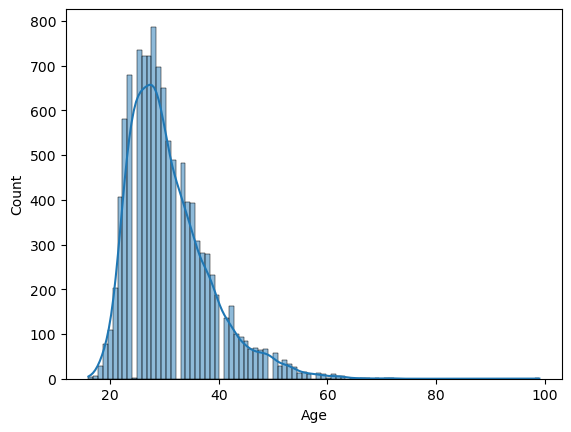

In [20]:
sns.histplot(df['Age'], kde=True)
plt.show()

In [21]:
df['ConvertedComp'].median()

57745.0

In [22]:
df.groupby('Gender')['ConvertedComp'].median()

Gender
Man                                                            57744.0
Man;Non-binary, genderqueer, or gender non-conforming          59520.0
Non-binary, genderqueer, or gender non-conforming              67142.0
Woman                                                          57708.0
Woman;Man                                                      21648.0
Woman;Man;Non-binary, genderqueer, or gender non-conforming    30244.0
Woman;Non-binary, genderqueer, or gender non-conforming        65535.5
Name: ConvertedComp, dtype: float64

In [23]:
Q1 = df['ConvertedComp'].quantile(0.25)
Q3 = df['ConvertedComp'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[df['ConvertedComp'] <= Q3 + 1.5*IQR]

In [24]:
import sqlite3
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m4_survey_data.sqlite"
r = requests.get(url)

with open("m4_survey_data.sqlite", "wb") as f:
    f.write(r.content)

In [25]:
conn = sqlite3.connect("m4_survey_data.sqlite")

In [39]:
query = """
select DatabaseDesireNextYear, count(*) as Count
from DatabaseDesireNextYear
group by DatabaseDesireNextYear
order by Count DESC
limit 5
"""

pd.read_sql_query(query, conn)

,DatabaseDesireNextYear,Count
0,PostgreSQL,4328
1,MongoDB,3649
2,Redis,3331
3,MySQL,3281
4,Elasticsearch,2856


In [40]:
query = """
select DatabaseDesireNextYear, count(*) as Count
from DatabaseDesireNextYear
group by DatabaseDesireNextYear
order by Count DESC
limit 5
"""

pd.read_sql_query(query, conn)

,DatabaseDesireNextYear,Count
0,PostgreSQL,4328
1,MongoDB,3649
2,Redis,3331
3,MySQL,3281
4,Elasticsearch,2856


In [41]:
conn.close()